In [4]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
_=pl.Config.set_tbl_cols(100000)
_=pl.Config.set_tbl_rows(10000)
_=pl.Config.set_tbl_width_chars(10000)
_=pl.Config.set_fmt_str_lengths(10000)

from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve

In [5]:
path = "/project/PlatigLab/users/yogi/ENCODE-RNA-Binding-Protein-Network-Modeling/analysis/06_first_order_SHAP_analysis/outputs/dpsi_vs_local_SHAP/all_partitions/dpsi_vs_local_SHAP_scatterplot_data_all_partitions.tsv.gz"

In [6]:
table = pd.read_csv(path, sep='\t', compression='gzip')

In [5]:
# Set significance threshold

# Create sig_df with significant events
sig_df = table[
    (table['dPSI'].abs() >= 0.01) & 
    (table['rMATS FDR'] <= 0.05)
].copy()

In [ ]:
# Given a dataframe and RBP -> make a 2x6 plot of dPSI vs CTRL - KD Local SHAP

def make_scatterplot_grid(data, RBP):
    
    # Filter the dataframe for the RBP
    plot_df = data[data["Feature"].str.contains(RBP, na=False)]
    
    # Get unique features and cell lines
    features = sorted(plot_df["Feature"].unique())
    cell_lines = ["HepG2", "K562"]
    
    # Create figure with 2 rows and 6 columns
    fig, axes = plt.subplots(2, 6, figsize=(30, 10), sharex=True, sharey=True)
    
    # Plot for each cell line (row) and feature (column)
    for row_idx, cell_line in enumerate(cell_lines):
        for col_idx, feature in enumerate(features):
            ax = axes[row_idx, col_idx]
            
            # Filter data for this specific feature and cell line
            subset = plot_df[(plot_df["Feature"] == feature) & 
                            (plot_df["Cell Line"] == cell_line)]
            
            if len(subset) > 0:
                # Create the scatter plot
                ax.scatter(subset["CTRL - KD Local SHAP"], subset["dPSI"], 
                          alpha=0.5, s=30)
            
            # Add quadrant lines at x=0 and y=0
            ax.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
            ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
            
            # Add grid
            ax.grid(True, alpha=0.3)
            
            # Parse feature name (format: RBP_position_binding)
            parts = feature.split('_')
            rbp_name = parts[0]
            position = parts[1]
            title = f"{rbp_name} Pos. {position}"
            
            # Add title with parsed feature name
            ax.set_title(title, fontsize=14, pad=10)
            
            # Increase tick label font size
            ax.tick_params(axis='both', which='major', labelsize=12)
        
        # Add cell line label to the left of the first plot in each row
        axes[row_idx, 0].text(-0.3, 0.5, cell_line, 
                              transform=axes[row_idx, 0].transAxes,
                              fontsize=20, fontweight='bold',
                              rotation=90, va='center', ha='center')
    
    # Add overall title
    fig.suptitle(f"{RBP} - Per Feature Analysis", fontsize=24, y=0.98)
    fig.supxlabel(r"$\Delta\phi$", fontsize=24)
    fig.supylabel(r"$\Delta\Psi$", fontsize=24)
    
    plt.tight_layout()
    plt.show()

In [7]:
def plot_roc_prc_scatter(data, feature):
    """
    Creates a 2x3 plot showing ROC, PRC, and scatterplot for a single feature across both cell lines.
    
    Parameters:
    -----------
    data : DataFrame
        Input dataframe containing the data
    feature : str
        Feature name (e.g., 'RBFOX2_3_binding')
    """
    
    cell_lines = ['HepG2', 'K562']
    
    # Parse feature name (format: RBP_position_binding)
    parts = feature.split('_')
    rbp_name = parts[0]
    position = parts[1]
    parsed_title = f"{rbp_name} Position {position}"
    
    # Create 2x3 subplot figure
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    for idx, cell_line in enumerate(cell_lines):
        
        # Subset for cell line and feature
        feature_subset = data[(data['Cell Line'] == cell_line) & 
                             (data['Feature'] == feature)].copy()
        
        # Create Significance column based on dPSI and FDR values
        feature_subset['Significance'] = (
            (feature_subset['dPSI'].abs() >= 0.1) & 
            (feature_subset['rMATS FDR'] <= 0.05)
        ).astype(int)
        
        # Calculate metrics
        total_events = len(feature_subset)
        num_significant = feature_subset['Significance'].sum()
        baseline = num_significant / total_events if total_events > 0 else 0
        
        # Check if we have both positive and negative examples
        if num_significant > 0 and num_significant < total_events:
            
            # Calculate AUROC and AUPRC
            auroc = roc_auc_score(feature_subset['Significance'], 
                                 feature_subset['CTRL - KD Local SHAP'].abs())
            auprc = average_precision_score(feature_subset['Significance'], 
                                           feature_subset['CTRL - KD Local SHAP'].abs())
            
            # Calculate curves
            fpr, tpr, _ = roc_curve(feature_subset['Significance'], 
                                   feature_subset['CTRL - KD Local SHAP'].abs())
            precision, recall, _ = precision_recall_curve(feature_subset['Significance'], 
                                                         feature_subset['CTRL - KD Local SHAP'].abs())
            
            # ROC curve (column 0)
            ax_roc = axes[idx, 0]
            ax_roc.plot(fpr, tpr, label=f'AUROC = {auroc:.3f}', linewidth=2)
            ax_roc.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=2)
            ax_roc.plot([], [], ' ', label=f'Total Events: {total_events:,}')
            ax_roc.plot([], [], ' ', label=f'Significant Events: {num_significant:,}')
            ax_roc.set_xlabel('False Positive Rate', fontsize=14, labelpad=10)
            ax_roc.set_ylabel('True Positive Rate', fontsize=14, labelpad=10)
            ax_roc.set_title(f'ROC Curve', fontsize=16, pad=15)
            ax_roc.legend(fontsize=12)
            ax_roc.tick_params(axis='both', labelsize=12)
            
            # PRC curve (column 1)
            ax_prc = axes[idx, 1]
            ax_prc.plot(recall, precision, label=f'AUPRC = {auprc:.3f}', linewidth=2)
            ax_prc.axhline(y=baseline, color='k', linestyle='--', 
                          label=f'Baseline = {baseline:.3f}', linewidth=2)
            ax_prc.plot([], [], ' ', label=f'Total Events: {total_events:,}')
            ax_prc.plot([], [], ' ', label=f'Significant Events: {num_significant:,}')
            ax_prc.set_xlabel('Recall', fontsize=14, labelpad=10)
            ax_prc.set_ylabel('Precision', fontsize=14, labelpad=10)
            ax_prc.set_title(f'Precision-Recall Curve', fontsize=16, pad=15)
            ax_prc.legend(fontsize=12)
            ax_prc.tick_params(axis='both', labelsize=12)
            
        else:
            # Handle case with insufficient data for ROC and PRC
            for col in range(2):
                axes[idx, col].text(0.5, 0.5, 
                                   f'Insufficient data\n' + 
                                   f'Significant events: {num_significant}/{total_events}',
                                   ha='center', va='center', fontsize=12)
                if col == 0:
                    axes[idx, col].set_title(f'ROC Curve', fontsize=16, pad=15)
                else:
                    axes[idx, col].set_title(f'Precision-Recall Curve', fontsize=16, pad=15)
        
        # Scatterplot (column 2)
        ax_scatter = axes[idx, 2]
        
        if len(feature_subset) > 0:
            # Determine significance: blue if |dPSI| >= 0.1 AND FDR <= 0.05, else grey
            colors = ['tab:blue' if (abs(dpsi) >= 0.1 and fdr <= 0.05) else 'lightgrey' 
                     for dpsi, fdr in zip(feature_subset["dPSI"], feature_subset["rMATS FDR"])]
            
            # Create the scatter plot with significance colors
            ax_scatter.scatter(feature_subset["CTRL - KD Local SHAP"], feature_subset["dPSI"], 
                      c=colors, alpha=0.5, s=30)
            
            # Calculate sign concordance for significant events only
            significant_subset = feature_subset[feature_subset['Significance'] == 1]
            if len(significant_subset) > 0:
                shap_values = significant_subset["CTRL - KD Local SHAP"]
                dpsi_values = significant_subset["dPSI"]
                same_sign = ((shap_values > 0) & (dpsi_values > 0)) | ((shap_values < 0) & (dpsi_values < 0))
                sign_concordance = (same_sign.sum() / len(significant_subset)) * 100
                
                # Add text box with sign concordance (bottom left, larger font)
                textstr = f'Sign concordance: {sign_concordance:.1f}%'
                props = dict(boxstyle='round', facecolor='white', edgecolor='black', alpha=0.8)
                ax_scatter.text(0.05, 0.05, textstr, transform=ax_scatter.transAxes, 
                              fontsize=14, verticalalignment='bottom', bbox=props)
        
        # Add quadrant lines at x=0 and y=0
        ax_scatter.axhline(y=0, color='black', linestyle='-', linewidth=1.5)
        ax_scatter.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
        
        # Add grid
        ax_scatter.grid(True, alpha=0.3)
        
        # Labels and title
        ax_scatter.set_xlabel(r"$\Delta\phi$ (CTRL - KD Local SHAP)", fontsize=14, labelpad=10)
        ax_scatter.set_ylabel(r"$\Delta\Psi$", fontsize=14, labelpad=10)
        ax_scatter.set_title(r"$\Delta\phi$ vs. $\Delta\Psi$" , fontsize=16, pad=15)
        ax_scatter.tick_params(axis='both', labelsize=12)
        
        # Add cell line label to the left of the first plot in each row
        axes[idx, 0].text(-0.25, 0.5, cell_line, 
                          transform=axes[idx, 0].transAxes,
                          fontsize=20, fontweight='bold',
                          rotation=90, va='center', ha='center')
    
    # Overall title with parsed feature name
    fig.suptitle(f'{parsed_title}', fontsize=18, y=0.995)
    plt.tight_layout()
    plt.show()

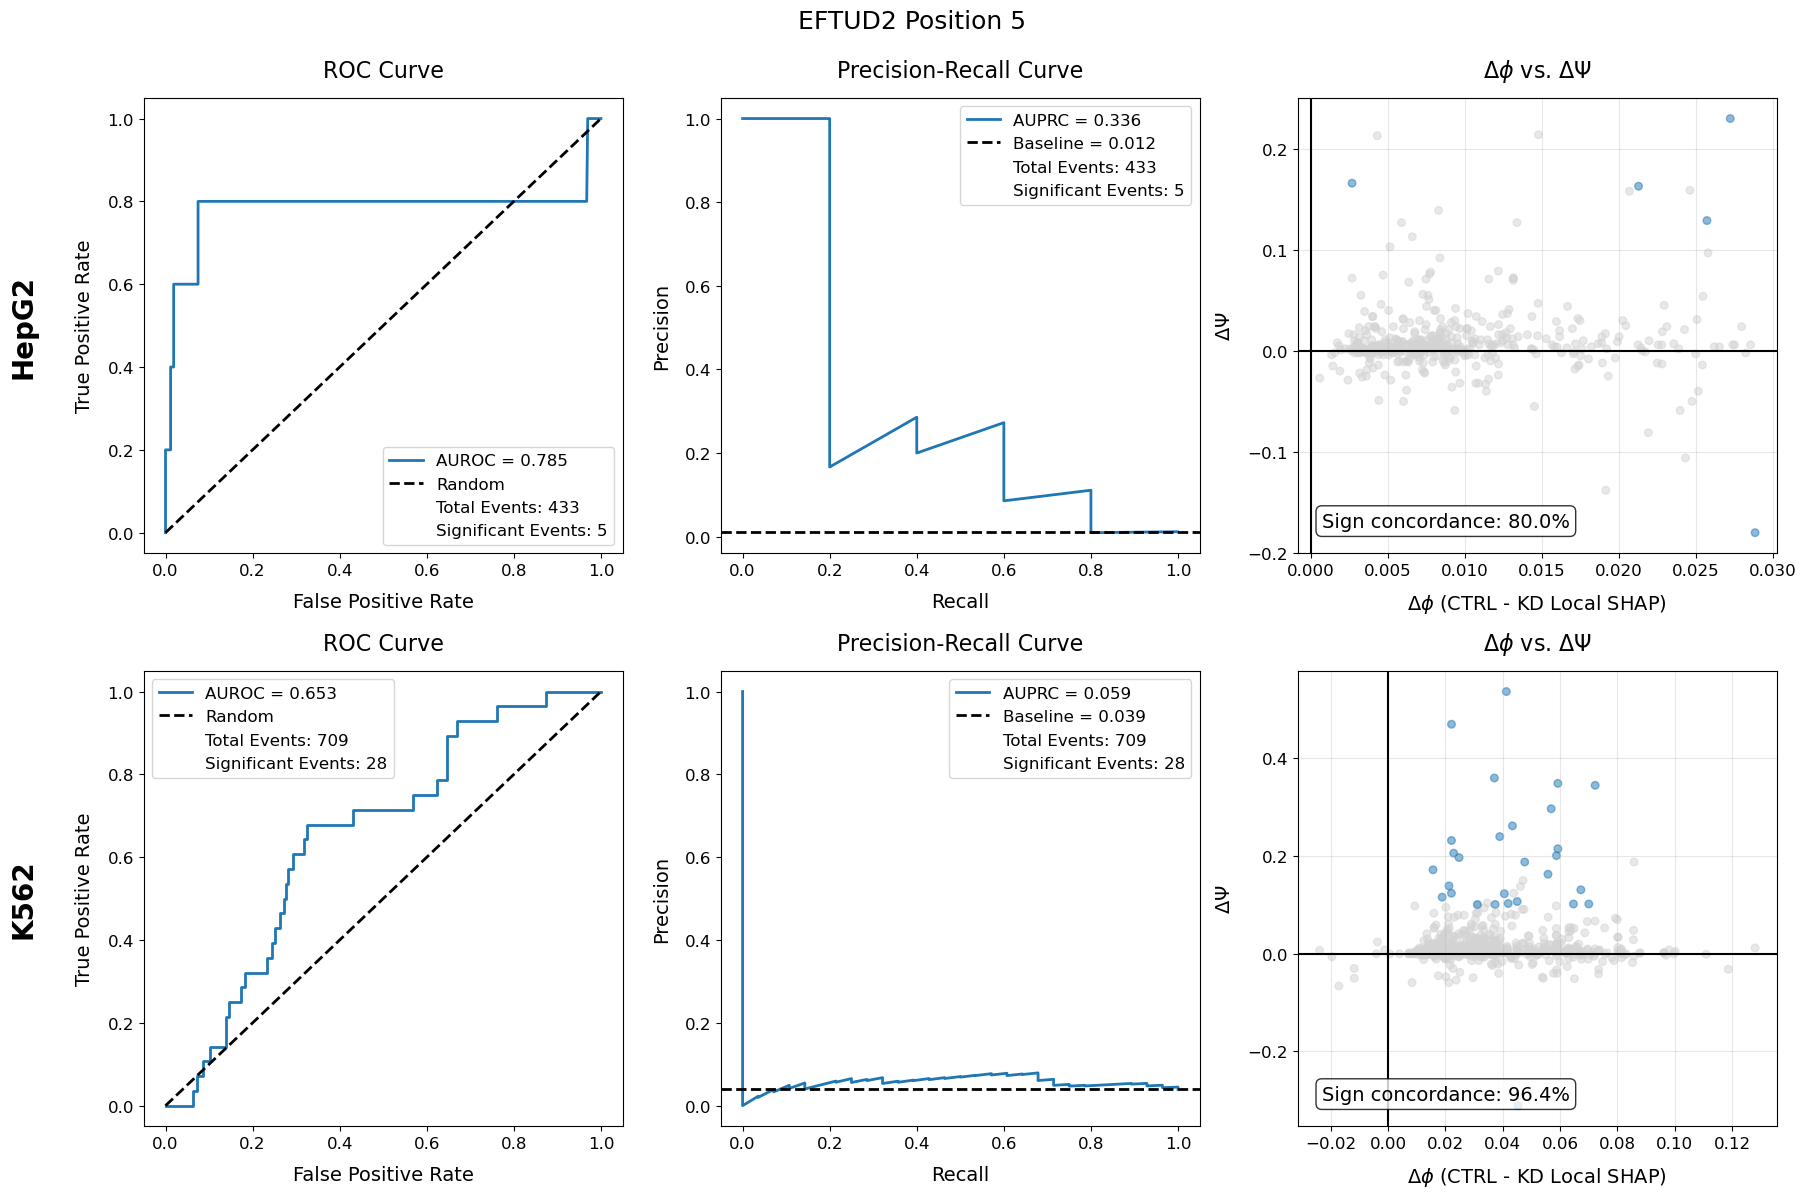

In [10]:
plot_roc_prc_scatter(table, "EFTUD2_5_binding")

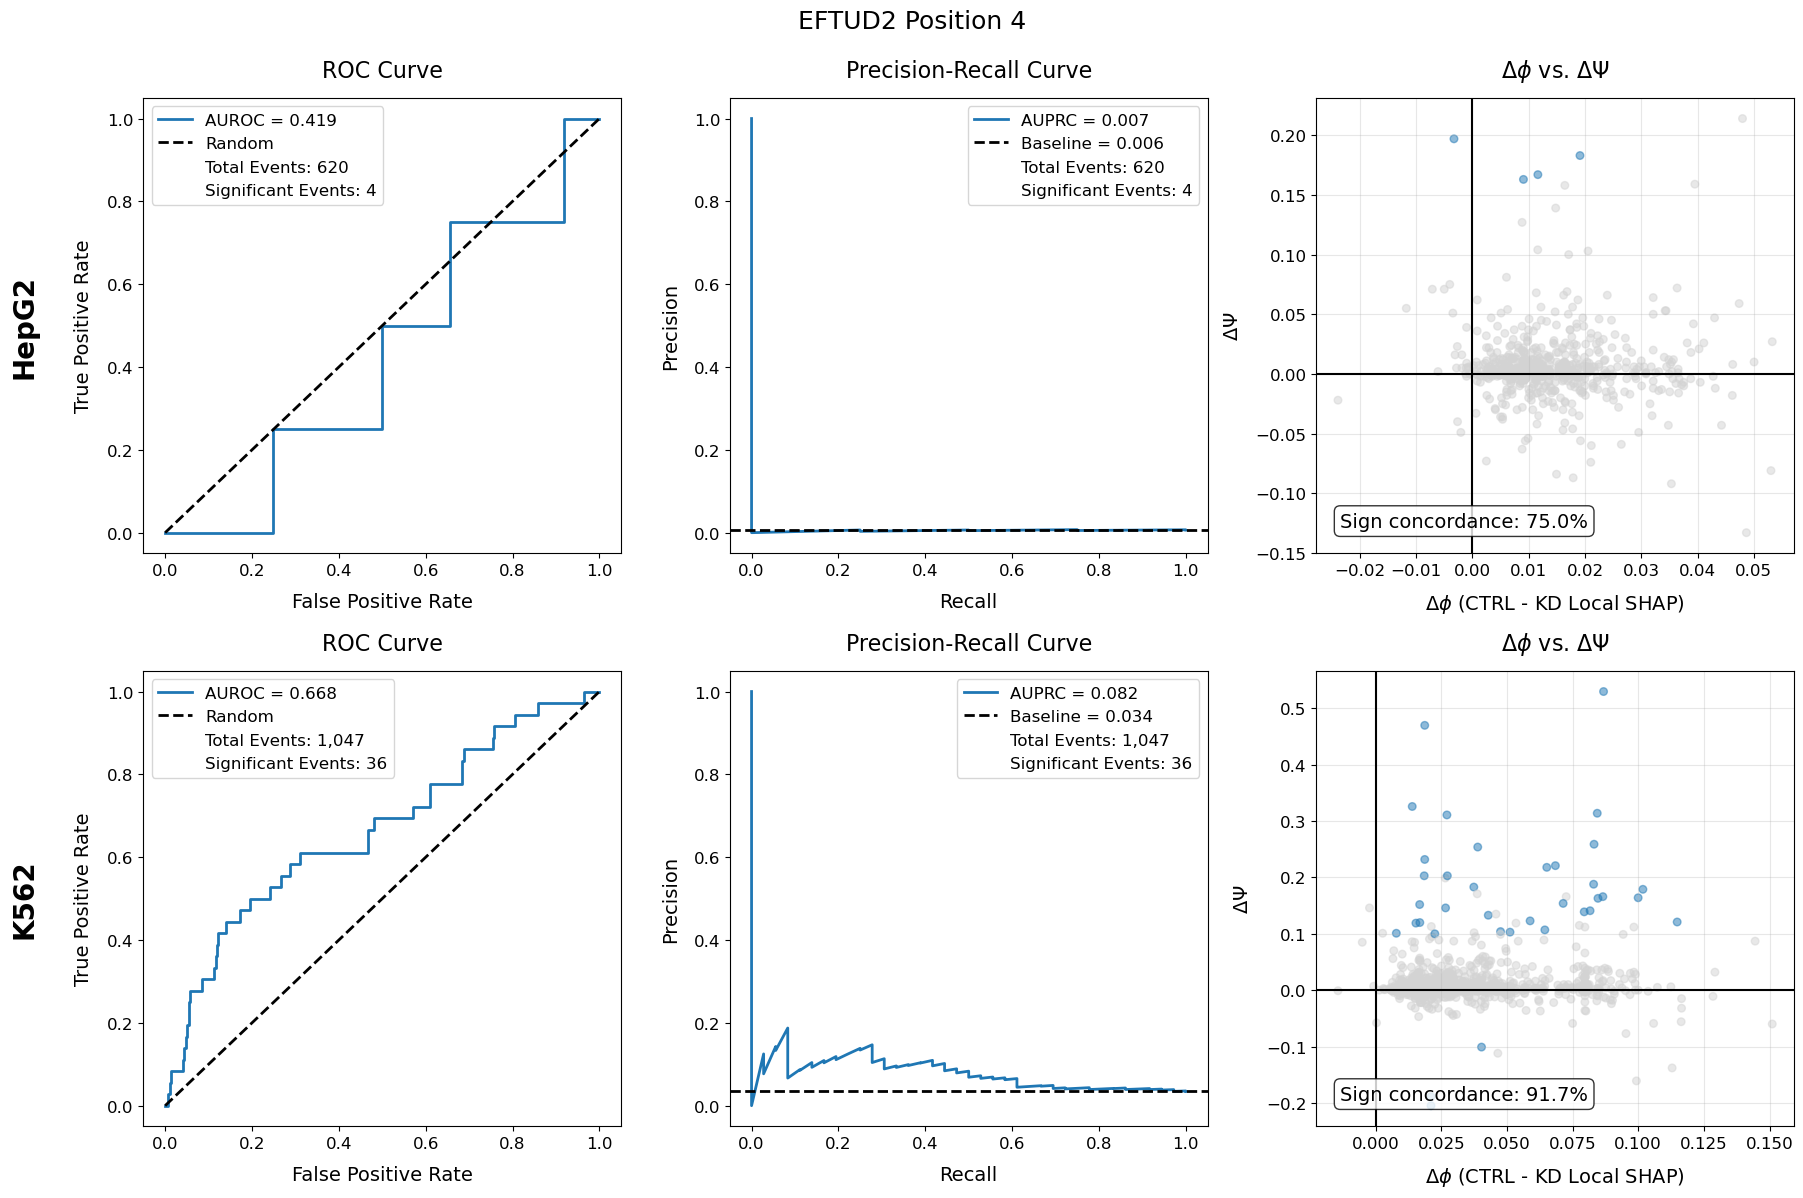

In [11]:
plot_roc_prc_scatter(table, "EFTUD2_4_binding")